# pySCENIC GRN inference - Group 3/4 MB snRNAseq


__Author:__ Vladoiu et al. 2019 Nature. 

__Date:__ 8 March 2023

__Outline:__ Group 3 and 4 MB snRNAseq datasets.

_Experiments:_


In [24]:
import os, glob, re, pickle
from functools import partial
from collections import OrderedDict
import operator as op
from cytoolz import compose

import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt

from arboreto.algo import _prepare_input, genie3, grnboost2
from dask.diagnostics import ProgressBar
from arboreto.utils import load_tf_names

from pyscenic.export import export2loom, add_scenic_metadata
from pyscenic.utils import load_motifs
from pyscenic.transform import df2regulons
from pyscenic.aucell import aucell
from pyscenic.binarization import binarize
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_binarization, plot_rss

In [25]:
# Set maximum number of jobs
sc.settings.njobs = 32

In [26]:
RESOURCES_FOLDERNAME = "/data/common/pySCENIC/resources"
DATA_FOLDERNAME = "/.mounts/labs/pailab/private/spai/data/scRNAseq/Vladiou_MBscRNAseq/processed/tumours_230308"
RESULTS_FOLDERNAME = '/u/icheong/SP_misc/MB_snRNAseq/results'
FIGURES_FOLDERNAME = '/u/icheong/SP_misc/MB_snRNAseqfigures'
AUXILLIARIES_FOLDERNAME = "/.mounts/labs/pailab/private/spai/data/PyScenic/cisTarget_databases"

In [27]:
# Ranking databases. Downloaded from cisTargetDB: https://resources.aertslab.org/cistarget/
RANKING_DBS_FNAMES = list(map(lambda fn: os.path.join(AUXILLIARIES_FOLDERNAME, fn),
                       ['hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather',
                       'hg38__refseq-r80__10kb_up_and_down_tss.mc9nr.genes_vs_motifs.rankings.feather']))
# Motif annotations. Downloaded from cisTargetDB: https://resources.aertslab.org/cistarget/
MOTIF_ANNOTATIONS_FNAME = os.path.join(RESOURCES_FOLDERNAME, 'motifs-v9-nr.hgnc-m0.001-o0.0.tbl')

__CLEANING METADATA AND QC__

In [28]:
DATASET_ID = 'G34MB'

In [29]:

COUNTS_MTX_FNAME = os.path.join(DATA_FOLDERNAME, 'TwoG3_Seurat-merged-SCTransform.rds_rawcounts.csv')
METADATA_FNAME = os.path.join(DATA_FOLDERNAME, 'TwoG3_Seurat-merged-SCTransform.rds_metadata.csv')

HS_TFS_FNAME = os.path.join(RESOURCES_FOLDERNAME, 'hs_tfs.txt')

# Output file
COUNTS_QC_MTX_FNAME = os.path.join(RESULTS_FOLDERNAME, 'HUMANCBL.qc.counts.csv')
ADJACENCIES_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.adjacencies.tsv'.format(DATASET_ID))
MOTIFS_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.motifs.csv'.format(DATASET_ID))
REGULONS_DAT_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.regulons.dat'.format(DATASET_ID))
AUCELL_MTX_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.auc.csv'.format(DATASET_ID))
BIN_MTX_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.bin.csv'.format(DATASET_ID))
THR_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.thresholds.csv'.format(DATASET_ID))
ANNDATA_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.h5ad'.format(DATASET_ID))
LOOM_FNAME = os.path.join(RESULTS_FOLDERNAME, '{}.loom'.format(DATASET_ID))

In [30]:
MOTIF_ANNOTATIONS_FNAME

'/data/common/pySCENIC/resources/motifs-v9-nr.hgnc-m0.001-o0.0.tbl'

In [31]:
#Create list of H.sapiens transcription factors.
pd_motifs = pd.read_csv(MOTIF_ANNOTATIONS_FNAME, sep='\t')

/tmp/ipykernel_246511/326047855.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  pd_motifs = pd.read_csv(MOTIF_ANNOTATIONS_FNAME, sep='\t')


In [32]:
hs_tfs = pd_motifs.gene_name.unique()
len(hs_tfs)

1839

In [33]:
with open(HS_TFS_FNAME, 'wt') as f:
    f.write('\n'.join(hs_tfs) + '\n')

In [34]:
df_counts = pd.read_table(COUNTS_MTX_FNAME, sep=',', index_col = 0)
df_counts.shape

(18687, 8825)

In [35]:
df_metadata = pd.read_csv(METADATA_FNAME, sep=',', index_col=1,nrows=10)#.T.reset_index().drop(columns=['index']) #, 'group #'])
#df_metadata.columns.name = ''

In [36]:
df_metadata.head()

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,cell_id
BT2016012,BT2016012_G3_AAACCTGAGCTGCCCA-1,3014,1405,BT2016012_G3,2.455209,3100,1405,3,3,BT2016012
BT2016012,BT2016012_G3_AAACCTGAGGAGTTGC-1,2943,1450,BT2016012_G3,2.310567,3060,1450,1,1,BT2016012
BT2016012,BT2016012_G3_AAACCTGAGTCGCCGT-1,3029,1567,BT2016012_G3,4.027732,3095,1567,9,9,BT2016012
BT2016012,BT2016012_G3_AAACCTGCATCGGAAG-1,3222,1493,BT2016012_G3,4.345127,3223,1493,5,5,BT2016012
BT2016012,BT2016012_G3_AAACCTGCATGGAATA-1,3467,1626,BT2016012_G3,2.826651,3407,1625,2,2,BT2016012


In [37]:
df_metadata = pd.read_csv(METADATA_FNAME, sep=',', index_col=1)
adata = sc.AnnData(X=df_counts.T.sort_index())
adata.obs = df_metadata.set_index('cell_id').sort_index()
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.raw = adata #Store non-log transformed data as raw. This data can be used via the use_raw parameters available for many functions.
df_counts_qc = adata.to_df()
sc.pp.normalize_total(adata, max_fraction=0.9)
sc.pp.log1p(adata)
adata

/tmp/ipykernel_246511/885661484.py:2: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = sc.AnnData(X=df_counts.T.sort_index())
/u/icheong/miniconda3/envs/pyscenic/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/u/icheong/miniconda3/envs/pyscenic/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 8825 × 18638
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'n_genes'
    var: 'n_cells'
    uns: 'log1p'

In [38]:
df_counts_qc.to_csv(COUNTS_QC_MTX_FNAME)

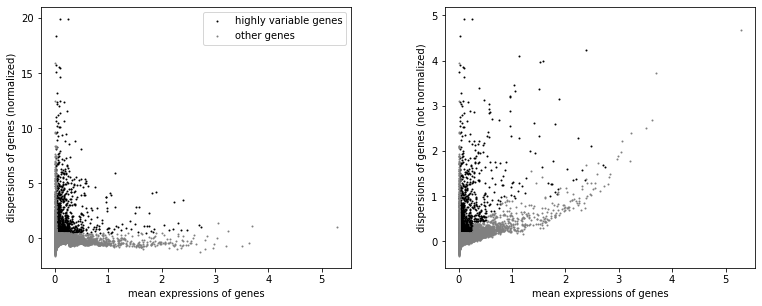

In [39]:
sc.pp.highly_variable_genes(adata)
sc.pl.highly_variable_genes(adata)

In [40]:
adata = adata[:, adata.var['highly_variable']]

In [41]:
sc.tl.pca(adata, svd_solver='arpack')

/u/icheong/miniconda3/envs/pyscenic/lib/python3.10/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [42]:
sc.tl.tsne(adata)

/u/icheong/miniconda3/envs/pyscenic/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


/u/icheong/miniconda3/envs/pyscenic/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


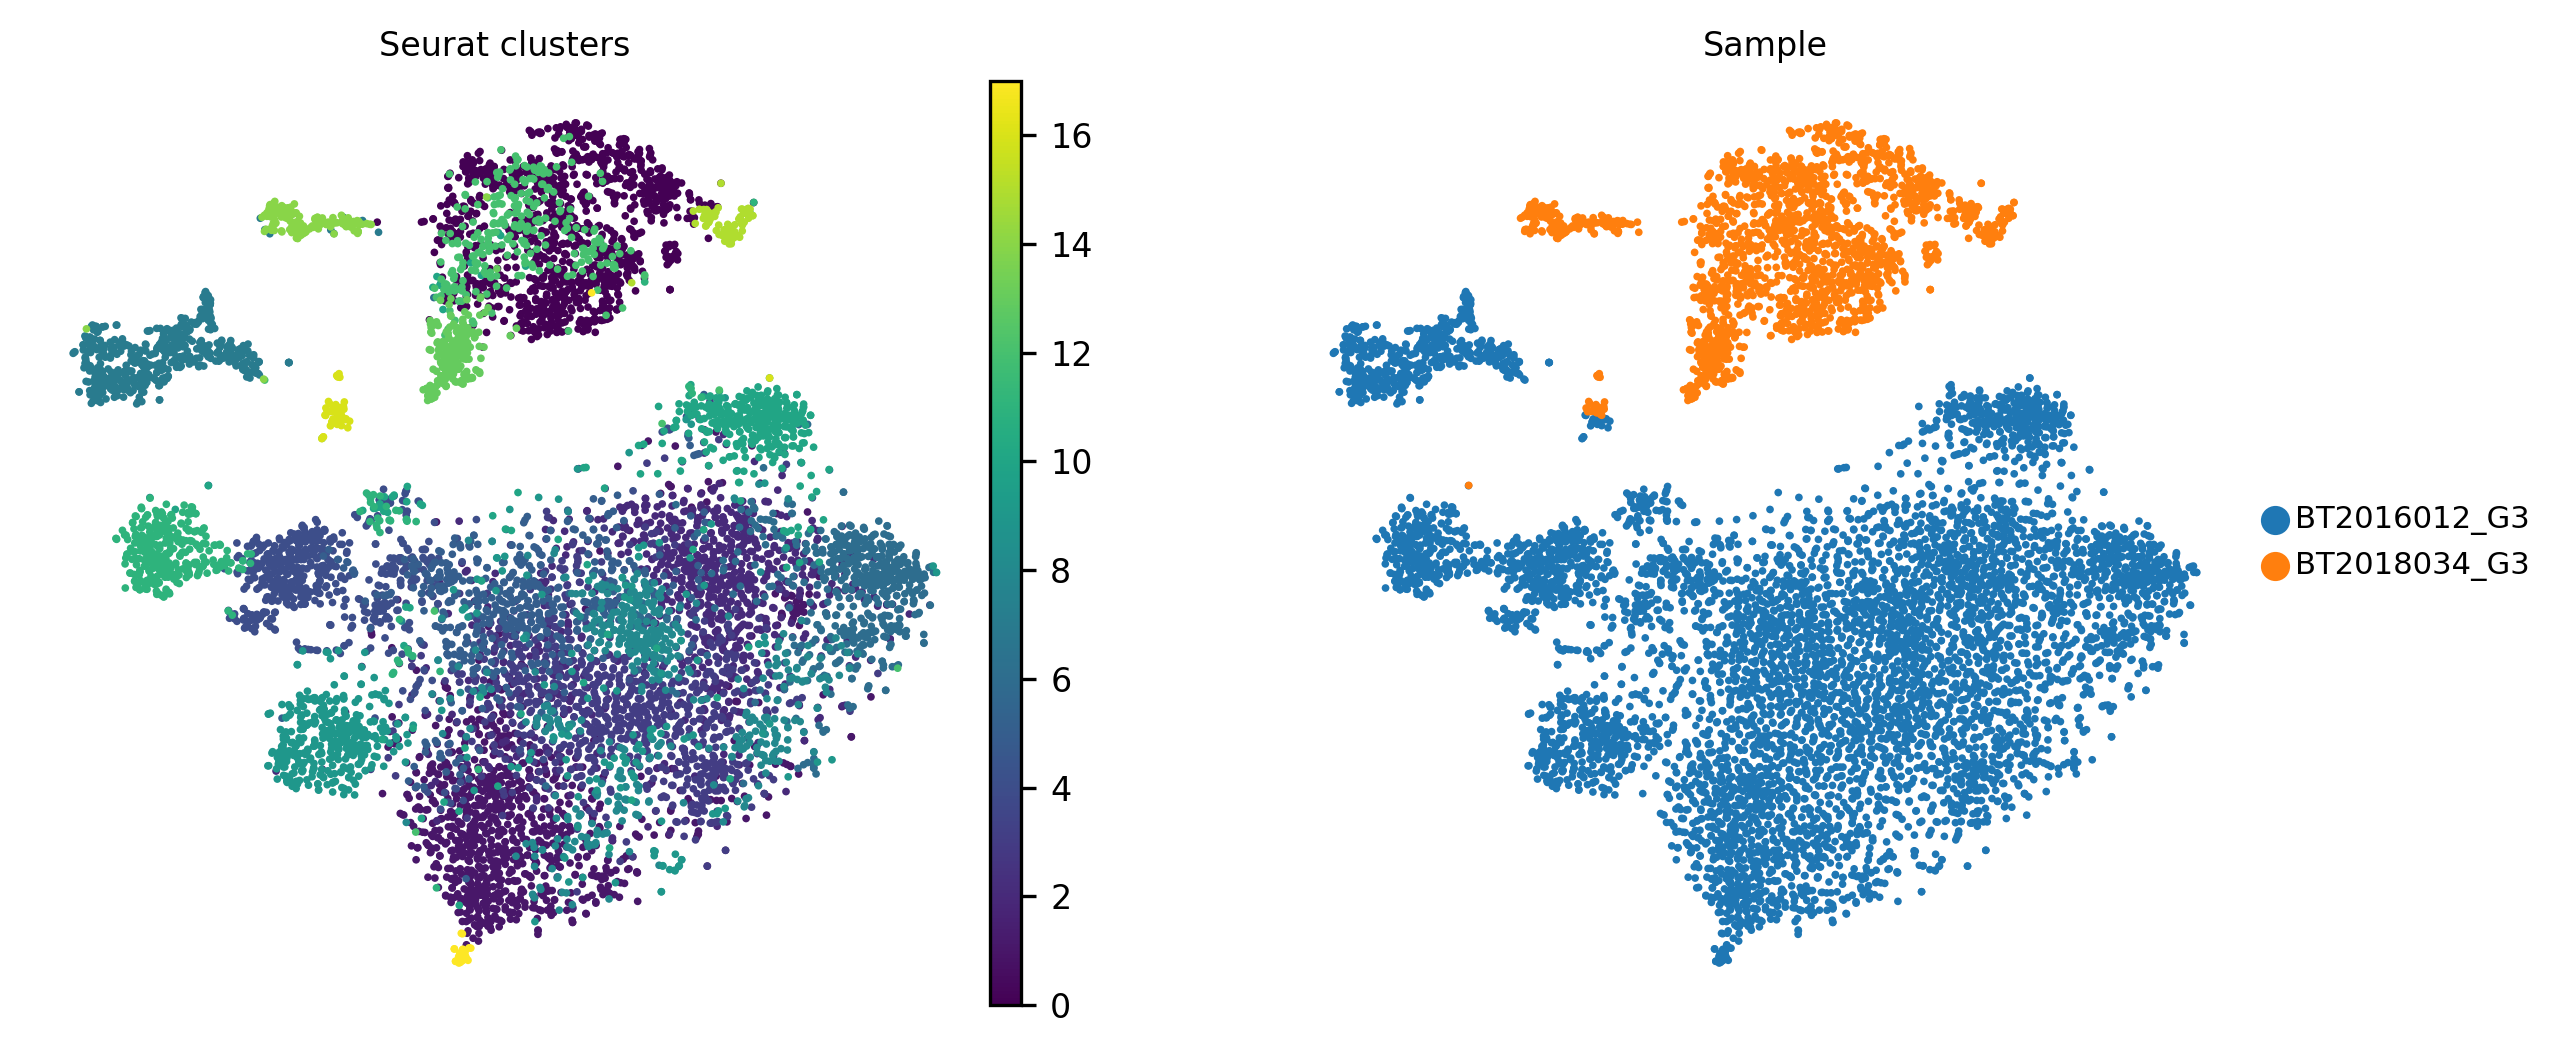

In [43]:
sc.set_figure_params(frameon=False, dpi=150, fontsize=8)
sc.pl.tsne(adata, color=['seurat_clusters', 'sample'], 
           title=['Seurat clusters', 'Sample'], ncols=2, use_raw=False)

### STEP 1: Network inference based on GRNBoost2 from CLI

For this step the CLI version of SCENIC is used. This step can be deployed on an High Performance Computing system.

_Output:_ List of adjacencies between a TF and its targets stored in `ADJACENCIES_FNAME`.

In [26]:
COUNTS_QC_MTX_FNAME

'/data/spai/PyScenic/mousebrain/results/HUMANCBL.qc.counts.csv'

In [27]:
HS_TFS_FNAME

'/data/spai/PyScenic/mousebrain/results/hs_tfs.txt'

In [28]:
ADJACENCIES_FNAME

'/data/spai/PyScenic/mousebrain/results/HUMANCBL.adjacencies.tsv'

In [4]:
from platform import python_version

print(python_version())

3.9.12


In [2]:
import dask as dk
print(dk.__version__)
import sys 
print(sys.executable)

2021.04.1
/u/oonabote/anaconda3/bin/python


In [28]:
##!pyscenic grn {COUNTS_QC_MTX_FNAME} {HS_TFS_FNAME} -o {ADJACENCIES_FNAME} --num_workers 32

/u/spai/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:369: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/u/spai/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:369: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/u/spai/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:369: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)

2023-02-08 14:09:56,790 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2023-

```
2019-06-13 17:32:45,044 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.
2019-06-13 17:33:07,766 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.
preparing dask client
parsing input
creating dask graph
32 partitions
computing dask graph
not shutting down client, client was created externally
finished
2019-06-13 18:04:23,356 - pyscenic.cli.pyscenic - INFO - Writing results to file.
```

### STEP 2-3: Regulon prediction aka cisTarget from CLI

For this step the CLI version of SCENIC is used. This step can be deployed on an High Performance Computing system.

_Output:_ List of adjacencies between a TF and its targets stored in `MOTIFS_FNAME`.

In [29]:
DBS_PARAM = ' '.join(RANKING_DBS_FNAMES)
DBS_PARAM

'/.mounts/labs/pailab/private/spai/data/PyScenic/cisTarget_databases/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather /.mounts/labs/pailab/private/spai/data/PyScenic/cisTarget_databases/hg38__refseq-r80__10kb_up_and_down_tss.mc9nr.genes_vs_motifs.rankings.feather'

In [30]:
MOTIF_ANNOTATIONS_FNAME

'/.mounts/labs/pailab/private/spai/data/PyScenic/resources/motifs-v9-nr.hgnc-m0.001-o0.0.tbl'

In [31]:
MOTIFS_FNAME
df = pd.read_csv('/data/spai/PyScenic/mousebrain/results/HUMANCBL.motifs.csv')

```
2019-06-14 09:49:42,740 - pyscenic.cli.pyscenic - INFO - Creating modules.
2019-06-14 09:49:45,193 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.
2019-06-14 09:52:42,315 - pyscenic.cli.pyscenic - INFO - Loading databases.
2019-06-14 09:52:42,316 - pyscenic.cli.pyscenic - INFO - Calculating regulons.
2019-06-14 10:18:06,172 - pyscenic.cli.pyscenic - INFO - Writing results to file.
```

In [32]:
df_motifs = load_motifs(MOTIFS_FNAME)

### STEP 4: Cellular enrichment aka AUCell

__REGULON CREATION__

Regulons can easily be created from this list of enriched motifs via `pyscenic.transform.df2regulons`. Here we provide an auxilliary function to carefully select the enriched motifs that contribute to the regulons.

In [36]:
def derive_regulons(motifs, db_names=('hg38__refseq-r80__10kb_up_and_down_tss.mc9nr.genes_vs_motifs.rankings', 
                                 'hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings'
                                 )):
    #motifs.columns = motifs.columns.droplevel(0)

    def contains(*elems):
        def f(context):
            return any(elem in context for elem in elems)
        return f

    # For the creation of regulons we only keep the 10-species databases and the activating modules. We also remove the
    # enriched motifs for the modules that were created using the method 'weight>50.0%' (because these modules are not part
    # of the default settings of modules_from_adjacencies anymore.
    motifs = motifs[
        np.fromiter(map(compose(op.not_, contains('weight>50.0%')), motifs.Context), dtype=bool) & \
        np.fromiter(map(contains(*db_names), motifs.Context), dtype=bool) & \
        np.fromiter(map(contains('activating'), motifs.Context), dtype=bool)]

    # We build regulons only using enriched motifs with a NES of 3.0 or higher; we take only directly annotated TFs or TF annotated
    # for an orthologous gene into account; and we only keep regulons with at least 10 genes.
    regulons = list(filter(lambda r: len(r) >= 10, df2regulons(motifs[(motifs['NES'] >= 3.0) 
                                                                      & ((motifs['Annotation'] == 'gene is directly annotated')
                                                                        | (motifs['Annotation'].str.startswith('gene is orthologous to')
                                                                           & motifs['Annotation'].str.endswith('which is directly annotated for motif')))
                                                                     ])))
    
    # Rename regulons, i.e. remove suffix.
    return list(map(lambda r: r.rename(r.transcription_factor), regulons))

In [37]:
df_motifs

AUC       NES  \
TF     MotifID                                                                  
CUX1   taipale_tf_pairs__CUX1_FOXO1_GTMAACANNNNNATCRAT...  0.084226  3.362568   
E2F8   hocomoco__E2F8_HUMAN.H11MO.0.D                      0.070619  3.464504   
EZH2   transfac_pro__M01253                                0.070624  3.263320   
HMGA2  transfac_pro__M07320                                0.070426  3.132865   
PDLIM5 hdpi__PDLIM5                                        0.085479  4.027920   
...                                                             ...       ...   
ZMIZ1  dbcorrdb__BRF1__ENCSR000DNW_1__m2                   0.103144  3.201962   
       dbcorrdb__SREBF2__ENCSR000DYT_1__m7                 0.107646  3.504429   
       dbcorrdb__CTCF__ENCSR000BHW_1__m2                   0.102045  3.128121   
       dbcorrdb__NELFE__ENCSR000DOF_1__m6                  0.107741  3.510833   
       dbcorrdb__EZH2__ENCSR000AQE_1__m9                   0.110157  3.673222   

                                                           MotifSimilarityQvalue  \
TF     MotifID                                                                     
CUX1   taipale_tf_pairs__CUX1_FOXO1_GTMAACANNNNNATCRAT...               0.000000   
E2F8   hocomoco__E2F8_HUMAN.H11MO.0.D                                   0.000000   
EZH2   transfac_pro__M01253                                             0.000059   
HMGA2  transfac_pro__M07320                                             0.000000   
PDLIM5 hdpi__PDLIM5                                                     0.000000   
...                                                                          ...   
ZMIZ1  dbcorrdb__BRF1__ENCSR000DNW_1__m2                                0.000000   
       dbcorrdb__SREBF2__ENCSR000DYT_1__m7                              0.000000   
       dbcorrdb__CTCF__ENCSR000BHW_1__m2                                0.000000   
       dbcorrdb__NELFE__ENCSR000DOF_1__m6                               0.000000   
       dbcorrdb__EZH2__ENCSR000AQE_1__m9                                0.000000   

                                                           OrthologousIdentity  \
TF     MotifID                                                                   
CUX1   taipale_tf_pairs__CUX1_FOXO1_GTMAACANNNNNATCRAT...                  1.0   
E2F8   hocomoco__E2F8_HUMAN.H11MO.0.D                                      1.0   
EZH2   transfac_pro__M01253                                                1.0   
HMGA2  transfac_pro__M07320                                                1.0   
PDLIM5 hdpi__PDLIM5                                                        1.0   
...                                                                        ...   
ZMIZ1  dbcorrdb__BRF1__ENCSR000DNW_1__m2                                   1.0   
       dbcorrdb__SREBF2__ENCSR000DYT_1__m7                                 1.0   
       dbcorrdb__CTCF__ENCSR000BHW_1__m2                                   1.0   
       dbcorrdb__NELFE__ENCSR000DOF_1__m6                                  1.0   
       dbcorrdb__EZH2__ENCSR000AQE_1__m9                                   1.0   

                                                                                                  Annotation  \
TF     MotifID                                                                                                 
CUX1   taipale_tf_pairs__CUX1_FOXO1_GTMAACANNNNNATCRAT...                         gene is directly annotated   
E2F8   hocomoco__E2F8_HUMAN.H11MO.0.D                                             gene is directly annotated   
EZH2   transfac_pro__M01253                                gene is annotated for similar motif dbcorrdb__...   
HMGA2  transfac_pro__M07320                                                       gene is directly annotated   
PDLIM5 hdpi__PDLIM5                                                               gene is directly annotated   
...                                                               

In [38]:
regulons = derive_regulons(df_motifs)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


In [39]:
REGULONS_DAT_FNAME = "/data/spai/PyScenic/mousebrain/results/regulons2.txt"

In [40]:
with open(REGULONS_DAT_FNAME, 'wb') as f:
    pickle.dump(regulons, f)

__AUCELL__

In [41]:
from pyscenic.cli.utils import load_exp_matrix
exp_mtx = load_exp_matrix(COUNTS_QC_MTX_FNAME)

In [42]:
%%time
auc_mtx = aucell(exp_mtx,regulons, num_workers=32)
auc_mtx.to_csv(AUCELL_MTX_FNAME)

CPU times: user 9.07 s, sys: 2.42 s, total: 11.5 s
Wall time: 13.9 s


```
CPU times: user 10.5 s, sys: 4.41 s, total: 14.9 s
Wall time: 14 s
```

In [43]:
auc_mtx = pd.read_csv(AUCELL_MTX_FNAME, index_col=0)

__AUCELL + tSNE PROJECTION__

We add all metadata derived from SCENIC to the `scanpy.AnnData` object.

In [44]:
add_scenic_metadata(adata, auc_mtx, regulons)

AnnData object with n_obs × n_vars = 9208 × 2630
    obs: 'index', 'seurat_clusters', 'total mRNA', 'fig_cell_type', 'sex', 'age', 'sample_id', 'S.Score', 'G2M.Score', 'Phase', 'n_genes', 'Regulon(ATF3)', 'Regulon(BRCA1)', 'Regulon(BRF2)', 'Regulon(CUX1)', 'Regulon(E2F2)', 'Regulon(E2F7)', 'Regulon(E2F8)', 'Regulon(EOMES)', 'Regulon(EZH2)', 'Regulon(FOXO1)', 'Regulon(HMGA2)', 'Regulon(LHX4)', 'Regulon(LUZP2)', 'Regulon(MYBL1)', 'Regulon(NFATC4)', 'Regulon(NFIB)', 'Regulon(OTX2)', 'Regulon(PAX5)', 'Regulon(PDLIM5)', 'Regulon(POU2F1)', 'Regulon(RAD21)', 'Regulon(RBMS1)', 'Regulon(SMARCA4)', 'Regulon(SOX11)', 'Regulon(SOX2)', 'Regulon(SOX4)', 'Regulon(SOX5)', 'Regulon(TCF7L1)', 'Regulon(TEAD2)', 'Regulon(TEAD4)', 'Regulon(THRB)', 'Regulon(ZMAT4)', 'Regulon(ZMIZ1)'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Regulon(ATF3)', 'Regulon(BRCA1)', 'Regulon(BRF2)', 'Regulon(CUX1)', 'Regulon(E2F2)', 'Regulon(E2F7)', 'Regulon(E2F8)', 'Regulon(EOMES)', 'Regulo

In [48]:
sc.tl.tsne(adata, use_rep='X_aucell')

/u/oonabote/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


In [ ]:
sc.set_figure_params(frameon=False, dpi=150, fontsize=8)
sc.pl.tsne(adata, color=['seurat_clusters', 'sample',], 
           title=['Seurat Clusters', 'sample',], ncols=2)
plt.savefig("humanbrain-secondtsne.pdf", dpi=600)

/u/oonabote/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/u/oonabote/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/u/oonabote/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


/u/oonabote/anaconda3/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


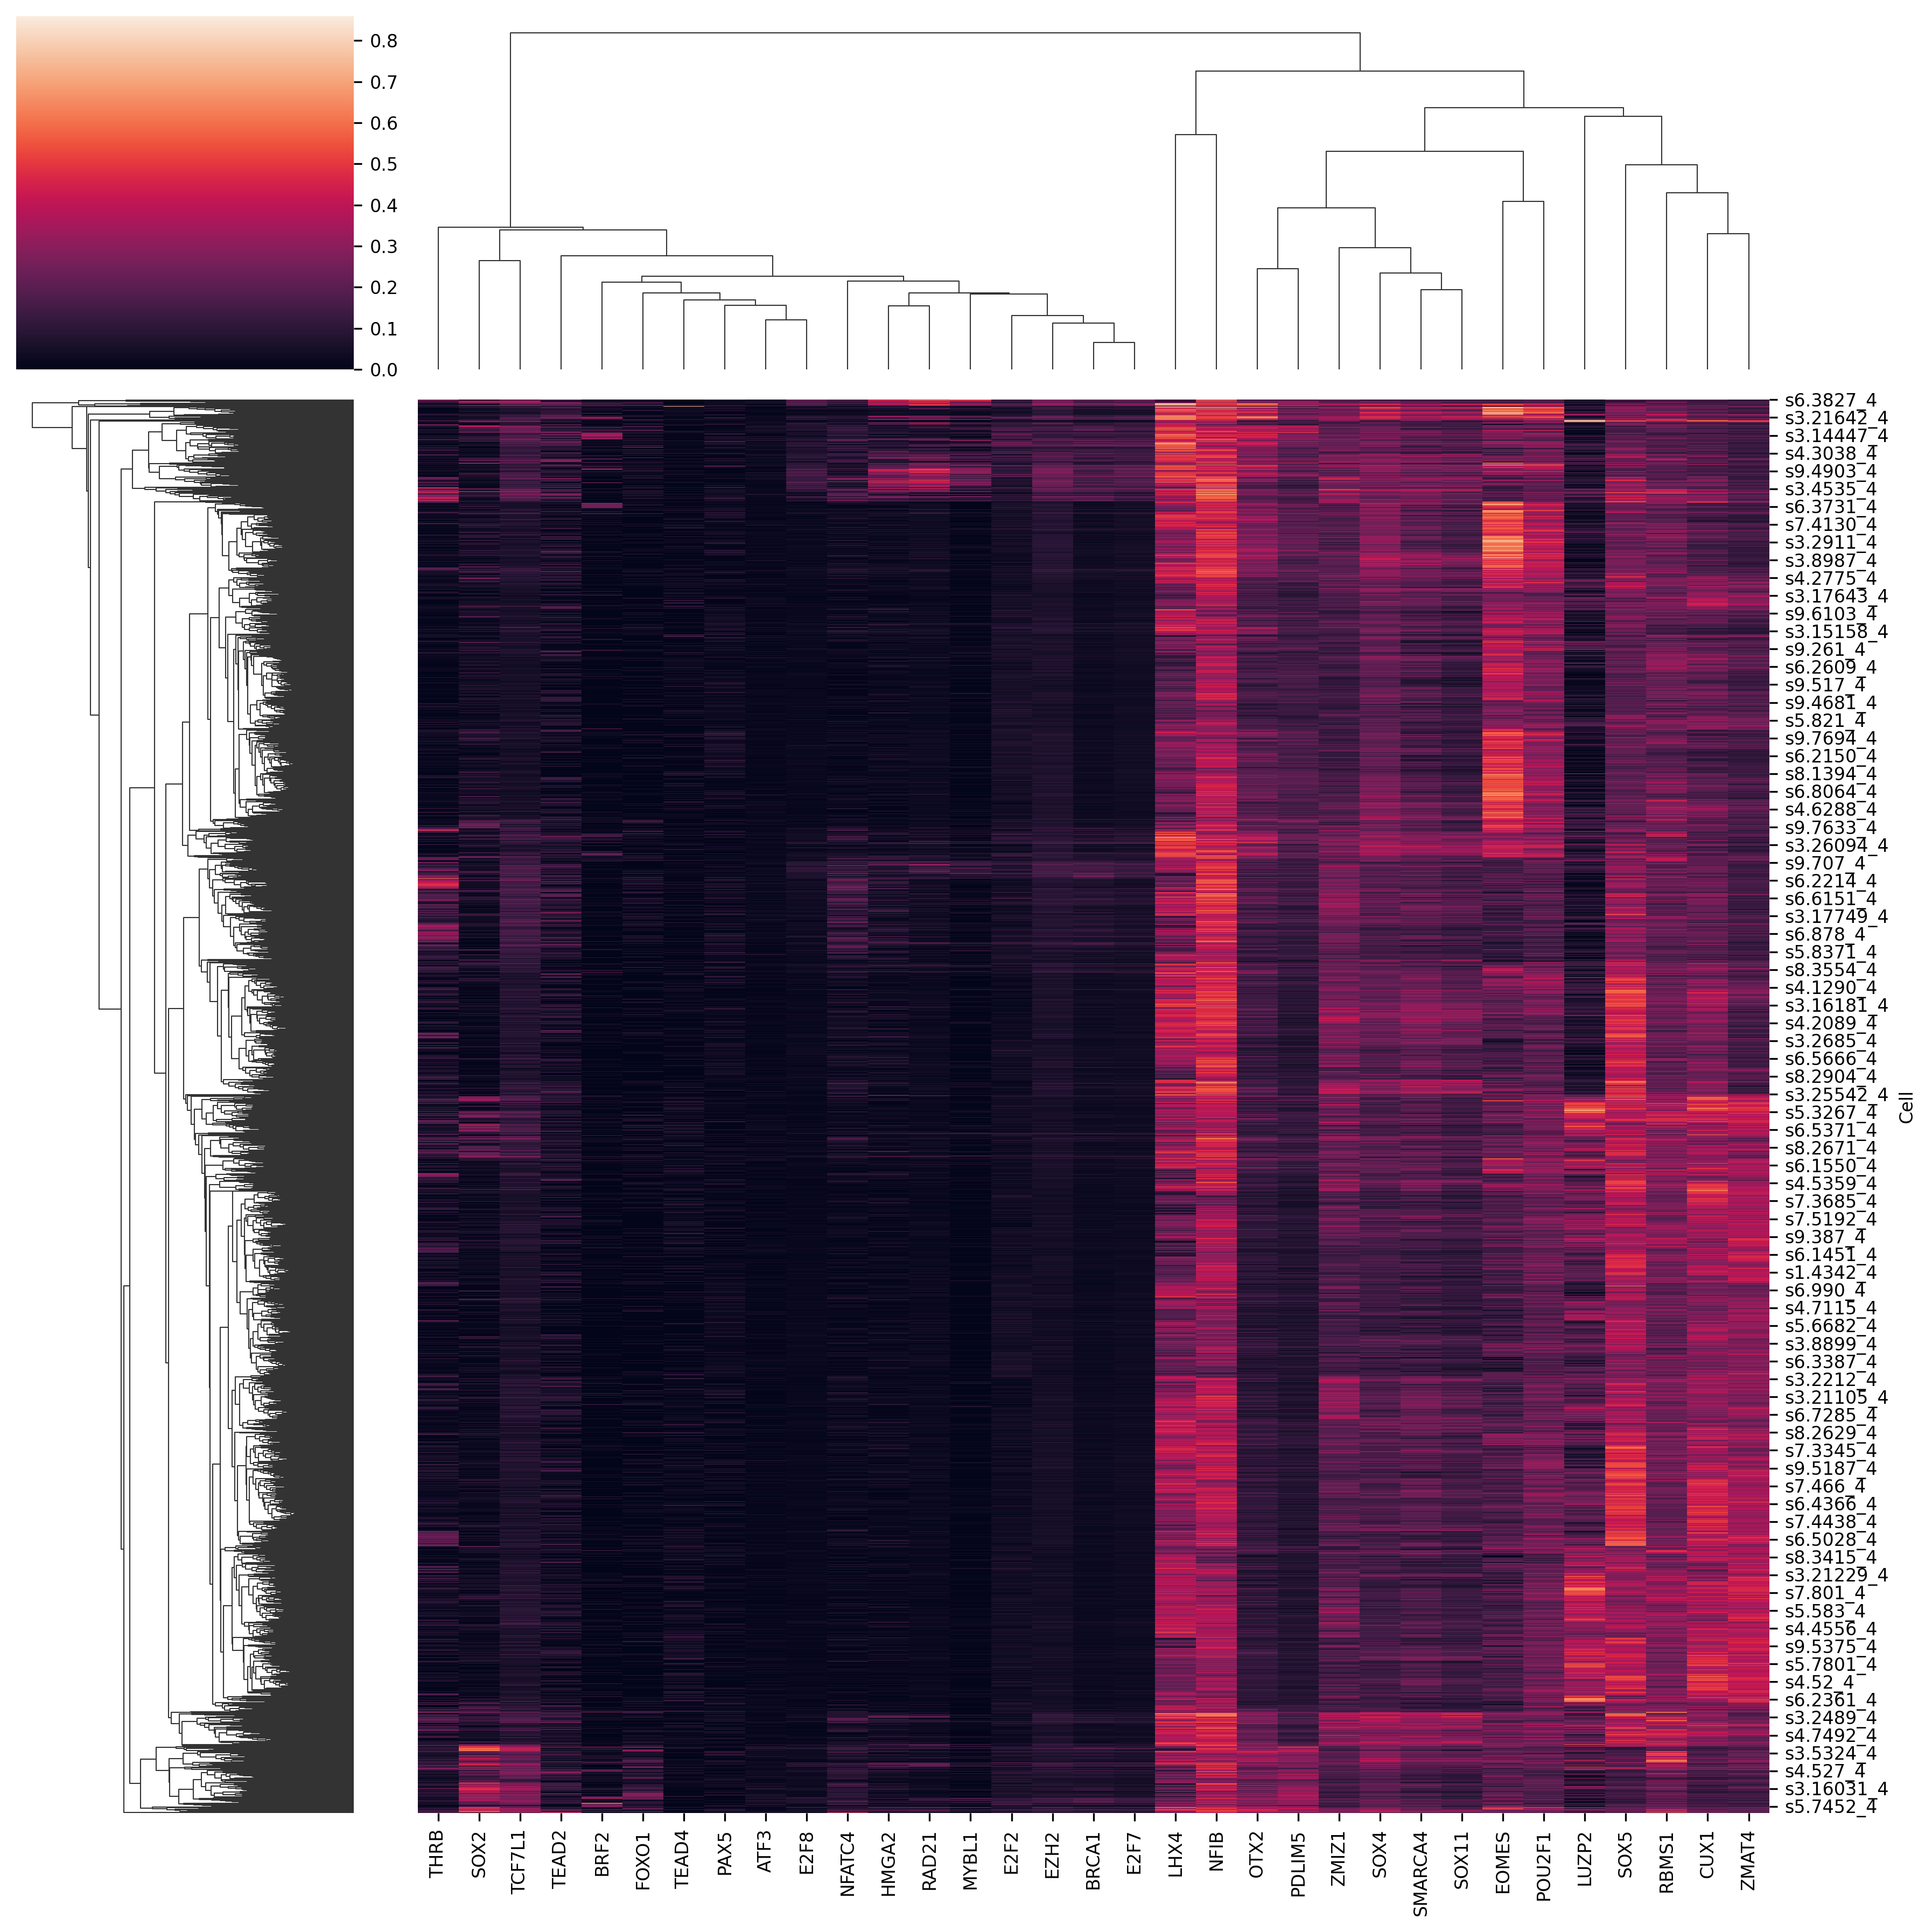

In [62]:
sns.clustermap(auc_mtx, figsize=(12,12))
plt.savefig("humanbrain-seaborn.matrix.pdf", dpi=600)

In [53]:
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss
import matplotlib.pyplot as plt
from adjustText import adjust_text
import seaborn as sns
from pyscenic.binarization import binarize

In [54]:
adata

AnnData object with n_obs × n_vars = 9208 × 2630
    obs: 'index', 'seurat_clusters', 'total mRNA', 'fig_cell_type', 'sex', 'age', 'sample_id', 'S.Score', 'G2M.Score', 'Phase', 'n_genes', 'Regulon(ATF3)', 'Regulon(BRCA1)', 'Regulon(BRF2)', 'Regulon(CUX1)', 'Regulon(E2F2)', 'Regulon(E2F7)', 'Regulon(E2F8)', 'Regulon(EOMES)', 'Regulon(EZH2)', 'Regulon(FOXO1)', 'Regulon(HMGA2)', 'Regulon(LHX4)', 'Regulon(LUZP2)', 'Regulon(MYBL1)', 'Regulon(NFATC4)', 'Regulon(NFIB)', 'Regulon(OTX2)', 'Regulon(PAX5)', 'Regulon(PDLIM5)', 'Regulon(POU2F1)', 'Regulon(RAD21)', 'Regulon(RBMS1)', 'Regulon(SMARCA4)', 'Regulon(SOX11)', 'Regulon(SOX2)', 'Regulon(SOX4)', 'Regulon(SOX5)', 'Regulon(TCF7L1)', 'Regulon(TEAD2)', 'Regulon(TEAD4)', 'Regulon(THRB)', 'Regulon(ZMAT4)', 'Regulon(ZMIZ1)'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Regulon(ATF3)', 'Regulon(BRCA1)', 'Regulon(BRF2)', 'Regulon(CUX1)', 'Regulon(E2F2)', 'Regulon(E2F7)', 'Regulon(E2F8)', 'Regulon(EOMES)', 'Regulo

In [57]:
rss_cellType = regulon_specificity_scores( auc_mtx, df_metadata.seurat_clusters)

In [58]:
rss_cellType

,ATF3,BRCA1,BRF2,CUX1,E2F2,E2F7,E2F8,EOMES,EZH2,FOXO1,...,SOX11,SOX2,SOX4,SOX5,TCF7L1,TEAD2,TEAD4,THRB,ZMAT4,ZMIZ1
H-RL,0.275202,0.291988,0.262764,0.255281,0.276708,0.288610,0.284900,0.258321,0.282699,0.263178,...,0.290464,0.267630,0.283633,0.255776,0.281659,0.281947,0.232705,0.250752,0.249806,0.274942
H-GCP,0.292401,0.312321,0.284620,0.277379,0.296311,0.309621,0.302100,0.279274,0.305885,0.270748,...,0.325203,0.288678,0.315589,0.277638,0.306390,0.300967,0.249273,0.261132,0.270005,0.303230
H-GN,0.484003,0.499852,0.313729,0.562758,0.511135,0.511115,0.495705,0.521888,0.527058,0.353260,...,0.526487,0.422304,0.527352,0.579697,0.521895,0.457398,0.399302,0.468911,0.568375,0.546373
H-eCN/UBC,0.338868,0.325707,0.256767,0.373463,0.361429,0.340858,0.330664,0.388680,0.350314,0.262778,...,0.347696,0.340169,0.366716,0.357756,0.343239,0.309393,0.325289,0.301925,0.368046,0.359550


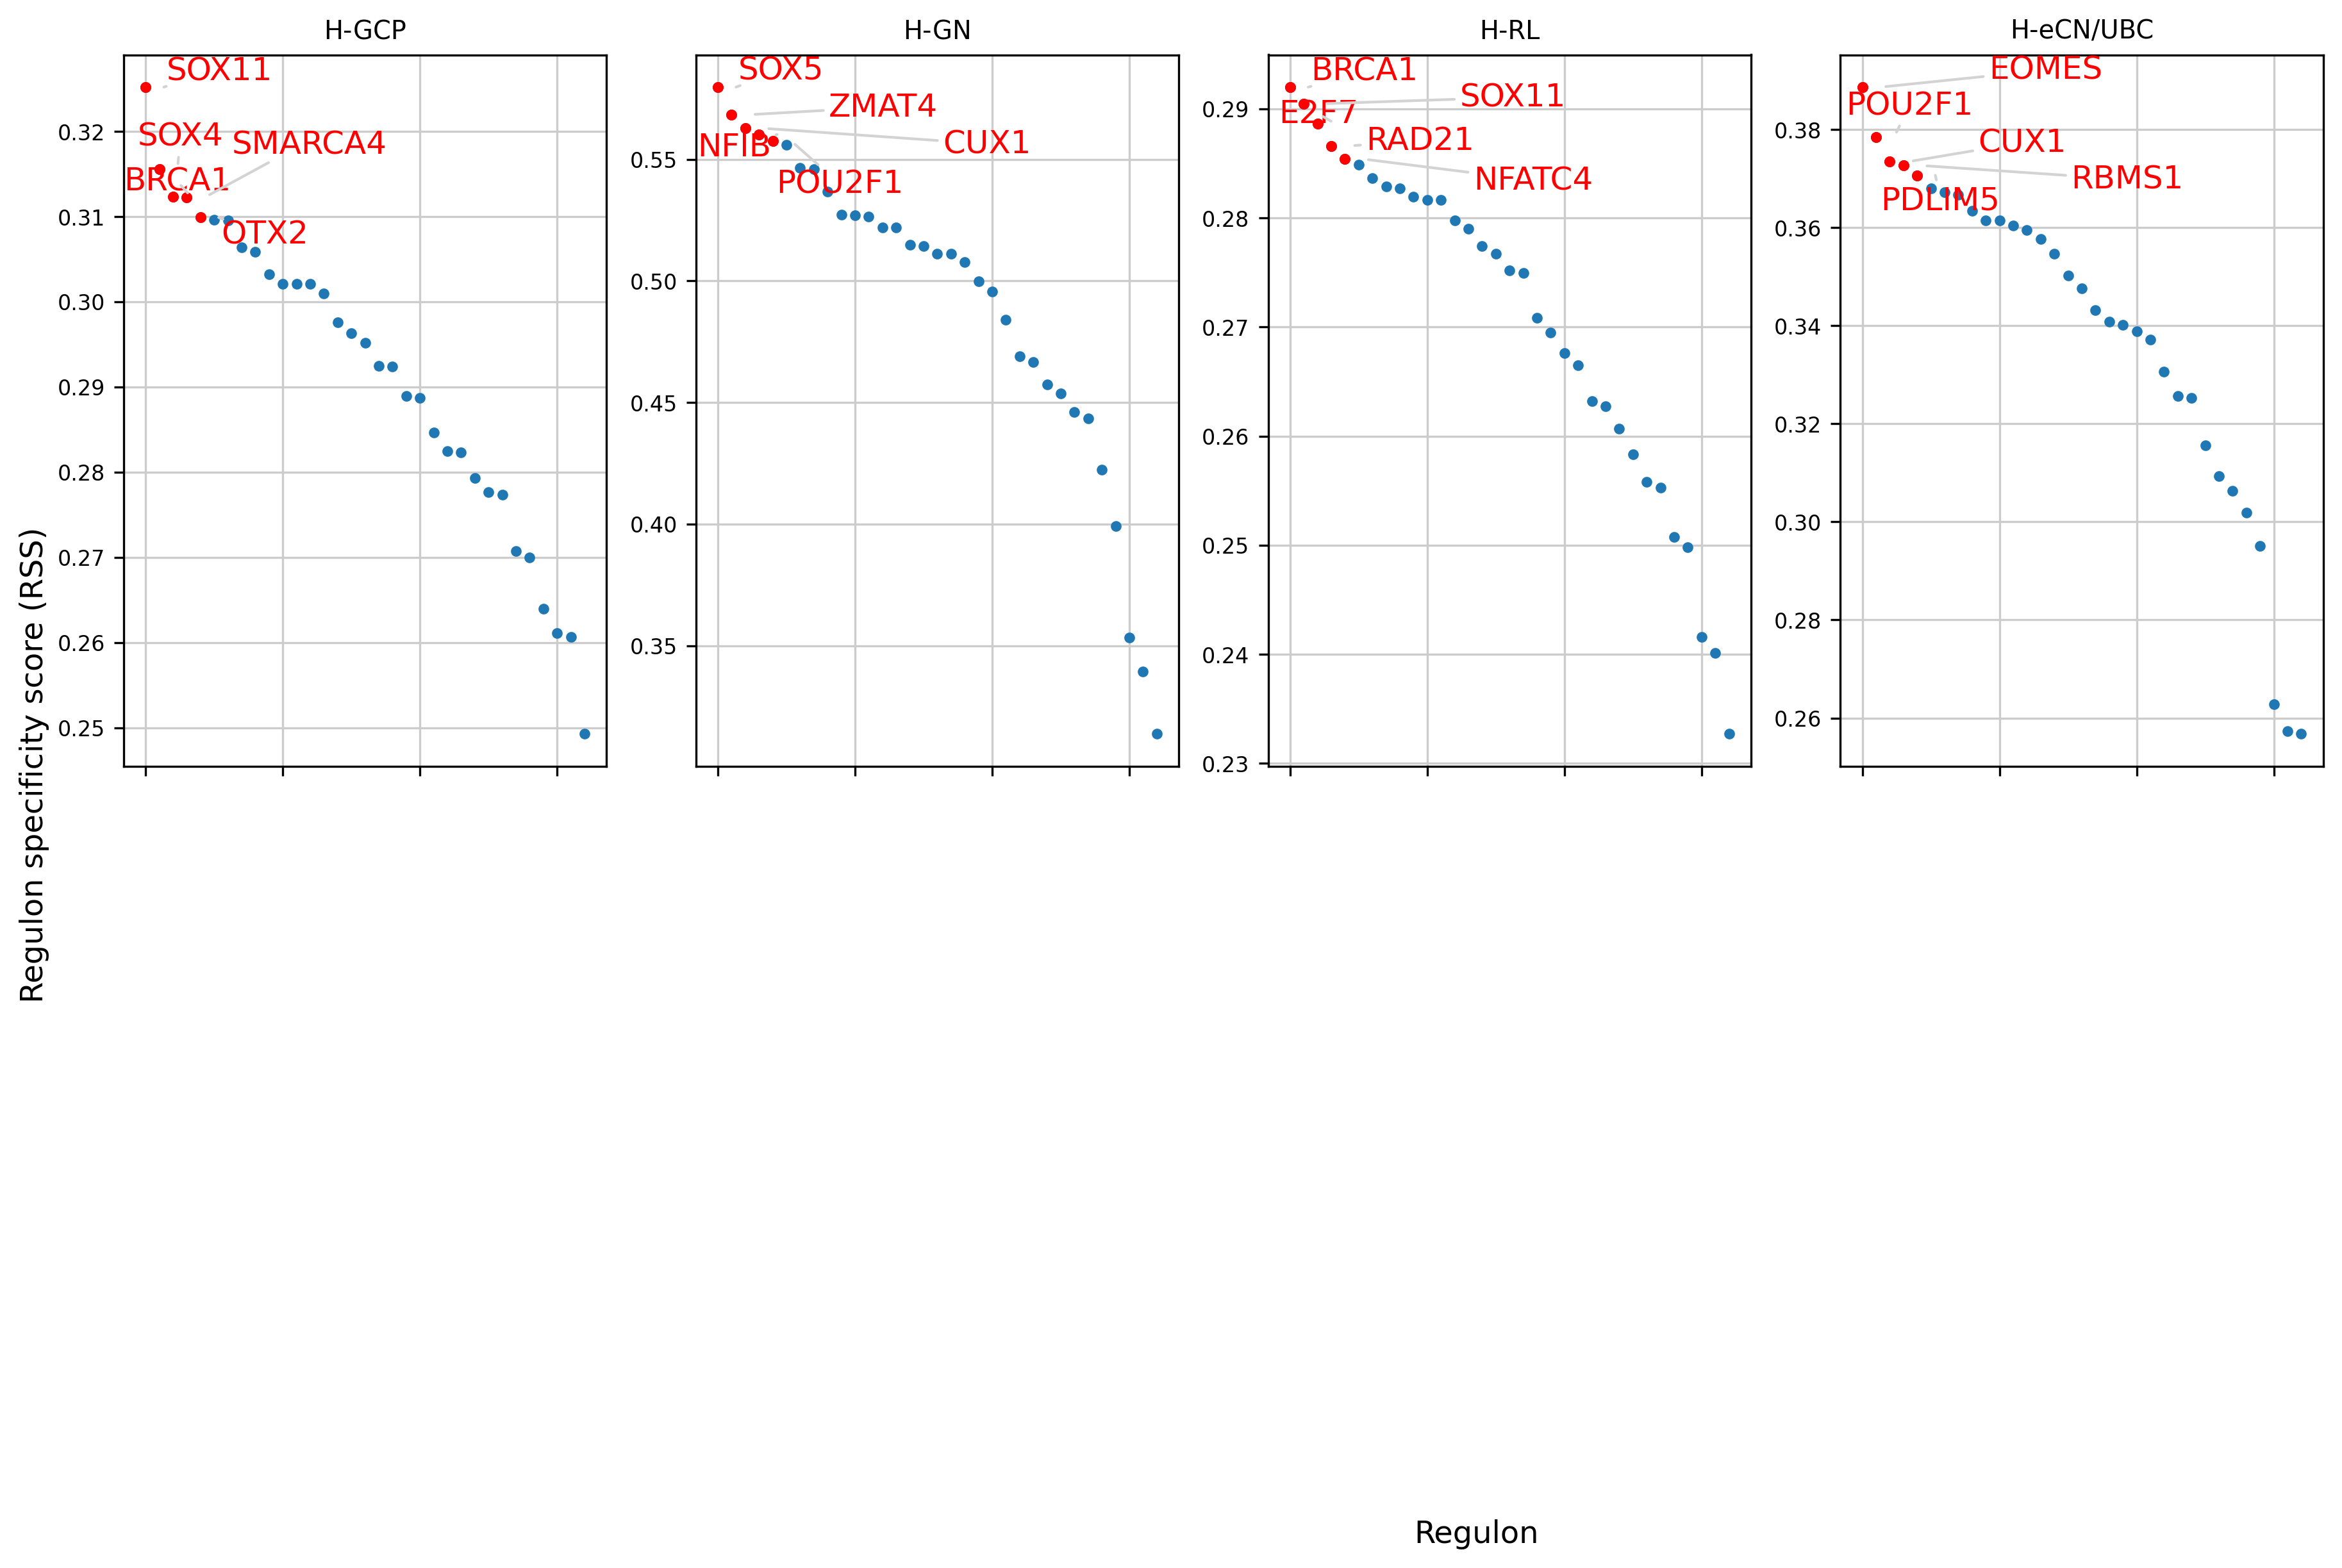

In [61]:
cats = sorted(list(set(df_metadata.seurat_clusters)))

fig = plt.figure(figsize=(15, 8))
for c,num in zip(cats, range(1,len(cats)+1)):
    x=rss_cellType.T[c]
    ax = fig.add_subplot(2,5,num)
    plot_rss(rss_cellType, c, top_n=5, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
plt.tight_layout()
plt.rcParams.update({
    'figure.autolayout': True,
        'figure.titlesize': 'large' ,
        'axes.labelsize': 'medium',
        'axes.titlesize':'large',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'
        })
plt.savefig("humanbrain-RSS-top5.pdf", dpi=600, bbox_inches = "tight")
plt.show()